<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
population.info()

Le tableau comporte 3 colonne(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


In [5]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur']*1000

In [7]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur': 'Population'}, inplace=True)

In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {dispo_alimentaire.shape[0]} observation(s) ou article(s) et {dispo_alimentaire.shape[1]} colonnes.")

Le tableau comporte 15605 observation(s) ou article(s) et 18 colonnes.


In [10]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 18 colonne(s)


In [11]:
#Affichage des 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)

In [13]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
liste_colonnes_dispo = dispo_alimentaire.columns.tolist() # on crée une liste avec tous les noms de colonnes
liste_non_modifie = ["Zone", "Produit", "Origine", "Disponibilité alimentaire (Kcal/personne/jour)", "Disponibilité alimentaire en quantité (kg/personne/an)", "Disponibilité de matière grasse en quantité (g/personne/jour)", "Disponibilité de protéines en quantité (g/personne/jour)"] # on crée une liste avec tous les noms de colonnes qu'on ne souhaite pas modifier

colonnes_a_modifier = list(set(liste_colonnes_dispo) - set(liste_non_modifie)) # on fait la différence entre les 2 pour avoir uniquement la liste des colonnes à modifier. On utilise l'opérateur '-' sur des sets de nos listes car plus rapide à traiter en python qu'une boucle for.

In [14]:
dispo_alimentaire[colonnes_a_modifier] *= (10**6) #conversion des colonnes concernées par 1 000 000 (millier de tonnes = million de kg)

In [15]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [16]:
#Afficher des dimensions du dataset
print(f"Le tableau comporte {aide_alimentaire.shape[0]} observation(s) ou article(s) et {aide_alimentaire.shape[1]} colonnes.")

Le tableau comporte 1475 observation(s) ou article(s) et 4 colonnes.


In [17]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 4 colonne(s)


In [18]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [19]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

In [20]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] *= 1000

In [21]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [22]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {sous_nutrition.shape[0]} observation(s) ou article(s) et {sous_nutrition.shape[1]} colonnes.")

Le tableau comporte 1218 observation(s) ou article(s) et 3 colonnes.


In [23]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s).".format(sous_nutrition.shape[1]))

Le tableau comporte 3 colonne(s).


In [24]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [25]:
#Conversion de la colonne sous nutrition en numérique
# sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])
# Il semble que la colonne comporte des valeurs qui ne sont pas des 'float' ('<0.1' par exemple ligne 60). Il faut donc utliser l'argument 'errors=coerce' pour forcer le changement de type.

In [26]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')
#Puis remplacement des NaN en 0
sous_nutrition['Valeur'].fillna(0)

0        8.6
1        8.8
2        8.9
3        9.7
4       10.5
        ... 
1213     0.0
1214     0.0
1215     0.0
1216     0.0
1217     0.0
Name: Valeur, Length: 1218, dtype: float64

In [27]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns={'Valeur': 'sous_nutrition'}, inplace=True)

In [28]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition'] *= (10**6)

In [29]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [30]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
# On va préparer le Dataframe sous_nutrition en modifiant la colonne année
print(sous_nutrition['Année'].unique())
# On s'assure qu'il n'y a que des intervalles de 3 ans dans le Dataframe

['2012-2014' '2013-2015' '2014-2016' '2015-2017' '2016-2018' '2017-2019']


In [31]:
sous_nutrition['Année'] = sous_nutrition['Année'].astype(str) #on transforme la colonne en type str pour pouvoir la formater plus facilement.
sous_nutrition['Année'] = sous_nutrition['Année'].str.split('-',expand=True)[0].astype(int) + 1
# On récupère la première année de chaque cellule de la colonne 'Année' à laquelle on ajoute 1 pour obtenir l'année voulue (ex : 2016-2018 devient 2017 en int en plus !)

In [32]:
# On vérifie le dataset
sous_nutrition.head(7)

,Zone,Année,sous_nutrition
0,Afghanistan,2013,8600000.0
1,Afghanistan,2014,8800000.0
2,Afghanistan,2015,8900000.0
3,Afghanistan,2016,9700000.0
4,Afghanistan,2017,10500000.0
5,Afghanistan,2018,11100000.0
6,Afrique du Sud,2013,2200000.0


In [33]:
# création d'un dataset population pour 2017
population_2017 = population.loc[population['Année'] == 2017]
# création d'un dataset sous_nutrition pour 2017
sous_nutrition_2017 = sous_nutrition.loc[sous_nutrition['Année'] == 2017]

In [34]:
# On vérifie que les deux colonnes 'Zone' ont bien les mêmes données :
manquants_sous_nutrition = list(set(population_2017['Zone'] ) - set(sous_nutrition_2017['Zone']))
# On cherche les pays qui ne sont PAS présents grâce à '~'.
manquants_population = list(set(sous_nutrition_2017['Zone'] ) - set(population_2017['Zone']))
print(f"Pays dans population mais pas dans sous_nutrition: {len(manquants_sous_nutrition)}")
print(f"Pays dans sous_nutrition mais pas dans population: {len(manquants_population)}")

Pays dans population mais pas dans sous_nutrition: 33
Pays dans sous_nutrition mais pas dans population: 0


In [35]:
#Il y a donc des pays dans 'population' qui ne se retrouvent pas dans 'sous_nutrition'. En revanche, on a tous les pays de 'sous-nutrition' qui sont avec la même orthographe dans 'population'.
# On va donc faire la jointure à gauche sur 'sous-nutrition' car tous les pays ont des correspondances dans l'autre Dataframe et on veut observer la sous_nutrition en premier lieu.

In [36]:
# jointure entre les deux datasets crées
proportion_sous_nutrition_2017 = pd.merge(sous_nutrition_2017, population_2017, on=['Zone', 'Année'], how="left")

In [37]:
#Remplacement des NaN par des 0
proportion_sous_nutrition_2017.fillna(0, inplace=True)

In [38]:
#Affichage du dataset
display(proportion_sous_nutrition_2017)

,Zone,Année,sous_nutrition,Population
0,Afghanistan,2017,10500000.0,36296113.0
1,Afrique du Sud,2017,3100000.0,57009756.0
2,Albanie,2017,100000.0,2884169.0
3,Algérie,2017,1300000.0,41389189.0
4,Allemagne,2017,0.0,82658409.0
...,...,...,...,...
198,Venezuela (République bolivarienne du),2017,8000000.0,29402484.0
199,Viet Nam,2017,6500000.0,94600648.0
200,Yémen,2017,0.0,27834819.0
201,Zambie,2017,0.0,16853599.0


In [39]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
print("Le nombre de personnes en sous nutrition est de {} millions.".format(proportion_sous_nutrition_2017['sous_nutrition'].sum()/1000000)) # Division par 10**6 pour afficher le nombre en millions et rendre cela plus lisible.
print("Il y a {:.2f} milliards d'êtres humains sur terre.".format(proportion_sous_nutrition_2017['Population'].sum()/10**9)) #idem ici en milliards.
print("Cela représente une proportion de {:.2f}%.".format(proportion_sous_nutrition_2017['sous_nutrition'].sum()*100/proportion_sous_nutrition_2017['Population'].sum()))

Le nombre de personnes en sous nutrition est de 535.7 millions.
Il y a 7.54 milliards d'êtres humains sur terre.
Cela représente une proportion de 7.10%.


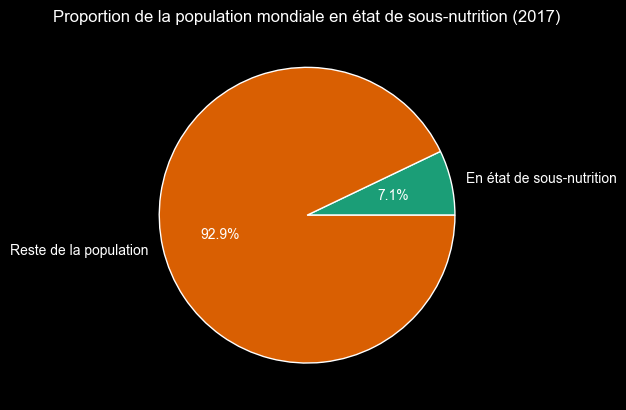

In [40]:
# On récupère les totaux déjà calculés
total_sous_nutrition = proportion_sous_nutrition_2017['sous_nutrition'].sum()
total_population = proportion_sous_nutrition_2017['Population'].sum()

# On calcule la part de la population "non en sous-nutrition"
reste_population = total_population - total_sous_nutrition

# On crée nos étiquettes et nos données
labels = ['En état de sous-nutrition', 'Reste de la population']
values = [total_sous_nutrition, reste_population]
colors = sns.color_palette('Dark2')
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title("Proportion de la population mondiale en état de sous-nutrition (2017)")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [41]:
#Combien mange en moyenne un être humain ? Source => Médecins sans frontières https://dictionnaire-droit-humanitaire.org/content/article/2/alimentation/ (en kcal/personne/j, moyenne mondiale)\n",
nutrition_moyenne_par_jour = 2400

Combien mange en moyenne un être humain ? [Source](https://dictionnaire-droit-humanitaire.org/content/article/2/alimentation/) (en kcal/personne/j, moyenne mondiale)

In [42]:
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


In [43]:
# On vérifie que les deux colonnes 'Zone' ont bien les mêmes données :
manquants_dispo_alimentaire = list(set(population_2017['Zone'] ) - set(dispo_alimentaire['Zone']))
# On cherche les pays qui ne sont PAS présents grâce à '~'.
manquants_population = list(set(dispo_alimentaire['Zone'] ) - set(population_2017['Zone']))
print(f"Pays dans population mais pas dans sous_nutrition: {len(manquants_dispo_alimentaire)}")
print(f"Pays dans sous_nutrition mais pas dans population: {len(manquants_population)}")

Pays dans population mais pas dans sous_nutrition: 64
Pays dans sous_nutrition mais pas dans population: 2


In [44]:
# On observe les manquants de dispo_alimentaire
manquants_dispo_alimentaire

['Saint-Siège',
 'Comores',
 'Îles Wallis-et-Futuna',
 'Liechtenstein',
 'Sainte-Hélène, Ascension et Tristan da Cunha',
 'Anguilla',
 'Îles Turques-et-Caïques',
 'Singapour',
 'Soudan du Sud',
 'Îles Falkland (Malvinas)',
 'Saint-Barthélemy',
 'Nioué',
 'Îles Marshall',
 'Îles Caïmanes',
 'Tokélaou',
 'Aruba',
 'Papouasie-Nouvelle-Guinée',
 'Îles Anglo-Normandes',
 'Sint Maarten  (partie néerlandaise)',
 'Martinique',
 'Palaos',
 'Guadeloupe',
 'Îles Vierges britanniques',
 'Îles Cook',
 'Andorre',
 'Érythrée',
 'Bhoutan',
 'Nauru',
 'Antilles néerlandaises (ex)',
 'Saint-Marin',
 'Guyane française',
 'Samoa américaines',
 'République arabe syrienne',
 'Saint-Pierre-et-Miquelon',
 'Bahreïn',
 'Porto Rico',
 'Tonga',
 'Tchéquie',
 'Micronésie (États fédérés de)',
 'Tuvalu',
 'Curaçao',
 'Îles Mariannes du Nord',
 'Saint-Martin (partie française)',
 'Îles Vierges américaines',
 'Groenland',
 'République démocratique du Congo',
 'Sahara occidental',
 'Palestine',
 'Qatar',
 "Royaume-Uni 

In [45]:
# On observe les manquants de population
manquants_population

['Royaume-Uni', 'Tchéquie (la)']

In [46]:
# On renomme les lignes de population pour qu'elles correspondent avec celles de dispo_alimentaire
population_2017.loc[population_2017['Zone'] == "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord", 'Zone'] = 'Royaume-Uni'
population_2017.loc[population_2017['Zone'] == "Tchéquie", 'Zone'] = 'Tchéquie (la)'

In [47]:
# On vérifie à nouveau
manquants_population = list(set(dispo_alimentaire['Zone'] ) - set(population_2017['Zone']))
print(f"Pays dans dispo_alimentaire mais pas dans population: {len(manquants_population)}")
#Tous les pays sont de dispo_alimentaire ont bien une correspondance dans population.

Pays dans dispo_alimentaire mais pas dans population: 0


In [48]:
# on peut maintenant ajouter la population au Dataframe dispo_alimentaire
dispo_alimentaire = pd.merge(dispo_alimentaire, population_2017, on='Zone', how="left")

In [49]:
#Affichage du nouveau dataframe
dispo_alimentaire

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000000.0,0.0,0.0,3000000.0,0.0,2000000.0,0.0,0.0,0.0,2017,636039.0
15601,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017,636039.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,636039.0
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,636039.0


In [50]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement en multipliant la dispo kcal/pers/j par la population.
dispo_alimentaire['dispo_kcal par jour'] = dispo_alimentaire['Disponibilité alimentaire (Kcal/personne/jour)'] * dispo_alimentaire['Population']

In [51]:
dispo_alimentaire

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal par jour
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,...,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017,36296113.0,181480565.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0,145184452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000000.0,...,0.0,3000000.0,0.0,2000000.0,0.0,0.0,0.0,2017,636039.0,28621755.0
15601,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017,636039.0,6996429.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,636039.0,0.0
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,636039.0,0.0


In [52]:
#Calcul du nombre d'humains pouvant être nourris
print("Il y a {:.2f} milliards d'êtres humains sur terre.".format(proportion_sous_nutrition_2017['Population'].sum()/10**9))
total_humains_nourris = round(dispo_alimentaire['dispo_kcal par jour'].sum() / nutrition_moyenne_par_jour)
print("Le nombre d'humains pouvant être nourris est de {:.2f} milliards.".format(total_humains_nourris/10**9))
print("On peut donc nourrir {:.2f} % de la population mondiale.".format(100*total_humains_nourris/dispo_alimentaire.groupby(by='Zone')['Population'].mean().sum()))

Il y a 7.54 milliards d'êtres humains sur terre.
Le nombre d'humains pouvant être nourris est de 8.83 milliards.
On peut donc nourrir 119.77 % de la population mondiale.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [53]:
#Transfert des données avec les végétaux dans un nouveau dataframe
dispo_alimentaire_vegetaux = dispo_alimentaire.loc[dispo_alimentaire['Origine'] == 'vegetale']

In [54]:
#Calcul du nombre de kcal disponible pour les végétaux
kcal_dispo_vegetaux_par_jour = dispo_alimentaire_vegetaux['dispo_kcal par jour'].sum()
print("Le nombre de kcal disponible par jour pour les végétaux est de {:.2f} milliards.".format(kcal_dispo_vegetaux_par_jour/10**9))

Le nombre de kcal disponible par jour pour les végétaux est de 17449.51 milliards.


In [55]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
total_humains_nourris_vegetaux = round(dispo_alimentaire_vegetaux['dispo_kcal par jour'].sum() / nutrition_moyenne_par_jour)
print("Le nombre d'humains pouvant être nourris avec les végétaux est de {:.2f} milliards.".format(total_humains_nourris_vegetaux/10**9))
print("On peut donc nourrir {:.2f} % de la population mondiale avec des végétaux.".format(100*total_humains_nourris_vegetaux/dispo_alimentaire.groupby(by='Zone')['Population'].mean().sum()))

Le nombre d'humains pouvant être nourris avec les végétaux est de 7.27 milliards.
On peut donc nourrir 98.66 % de la population mondiale avec des végétaux.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [56]:
#Calcul de la disponibilité totale
dispo_totale = dispo_alimentaire['Disponibilité intérieure'].sum()
print("La disponibilité totale est de {} milliards de kgs par jour.".format(dispo_totale/(10**9)))

La disponibilité totale est de 9848.994 milliards de kgs par jour.


In [57]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
liste_boucle = ['Aliments pour animaux', 'Pertes', 'Nourriture']

for elt in liste_boucle:
    (print(f"La Dispo de {elt} est de {dispo_alimentaire[elt].sum()/(10**9):.1f} milliards kg, cela représente {dispo_alimentaire[elt].sum()*100/dispo_totale:.2f}% de la dispo totale."))

La Dispo de Aliments pour animaux est de 1304.2 milliards kg, cela représente 13.24% de la dispo totale.
La Dispo de Pertes est de 453.7 milliards kg, cela représente 4.61% de la dispo totale.
La Dispo de Nourriture est de 4876.3 milliards kg, cela représente 49.51% de la dispo totale.


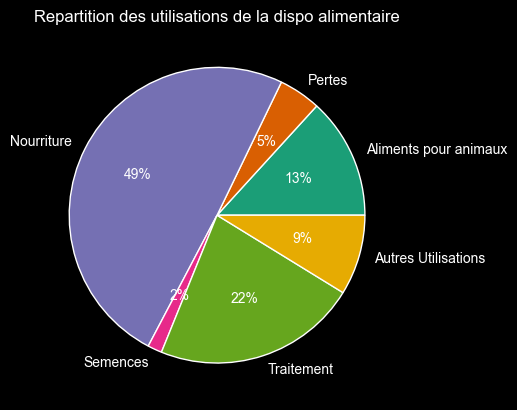

In [58]:
# si on veut observer toutes les utilisations on peut créer une liste qui va contenir la somme totale pour chaque catégorie
liste_boucle_utilisation_dispo = ['Aliments pour animaux', 'Pertes', 'Nourriture', 'Semences', 'Traitement', 'Autres Utilisations'] # Ici on a une liste de chaque catégorie sur laquelle on va itérer
categories_utilisation_dispo = [] # Ici on a une liste vide qui va accueillir les totaux
    
for elt in liste_boucle_utilisation_dispo: # la boucle for pour ajouter les totaux à notre liste vide
    categories_utilisation_dispo.append(dispo_alimentaire[elt].sum())

# création du graphique
colors = sns.color_palette('Dark2')
plt.title("Repartition des utilisations de la dispo alimentaire")
plt.pie(categories_utilisation_dispo, labels=liste_boucle_utilisation_dispo, colors=colors, autopct='%.0f%%')
plt.show()

In [59]:
#On peut faire pareil pour la provenance de la dispo
liste_boucle_provenance_dispo = ['Production', 'Importations - Quantité', 'Exportations - Quantité', 'Variation de stock'] # Ici, on a une liste de chaque catégorie sur laquelle on va itérer
df_total_balance_provenance_dispo = dispo_alimentaire[liste_boucle_provenance_dispo].sum().reset_index() # création du df avec les sommes de chaque catégorie

In [60]:
df_total_balance_provenance_dispo

,index,0
0,Production,1.000968e+13
1,Importations - Quantité,1.296053e+12
2,Exportations - Quantité,1.352158e+12
3,Variation de stock,-1.044020e+11


In [61]:
df_total_balance_provenance_dispo.columns = ['Catégorie', 'Valeur_totale en milliards de kgs'] # On nomme nos colonnes
df_total_balance_provenance_dispo['Valeur_totale en milliards de kgs'] /= 10**9 # Conversion en milliard pour plus de lisibilité

In [62]:
df_total_balance_provenance_dispo['Valeur_totale en milliards de kgs'] = pd.to_numeric(df_total_balance_provenance_dispo['Valeur_totale en milliards de kgs'], errors='coerce') # Conversion en float pour pouvoir faire un * -1 sur les exportations et qu'elles soient représentées comme négatives
df_total_balance_provenance_dispo.at[2, 'Valeur_totale en milliards de kgs'] *= -1 # l'argument "2" fait référence à la ligne exportations
df_total_balance_provenance_dispo#vérification de nos opérations

,Catégorie,Valeur_totale en milliards de kgs
0,Production,10009.680
1,Importations - Quantité,1296.053
2,Exportations - Quantité,-1352.158
3,Variation de stock,-104.402


In [63]:
# On renomme nos colonnes pour plus de lisibilité
df_total_balance_provenance_dispo.loc[df_total_balance_provenance_dispo['Catégorie'] == 'Exportations - Quantité', 'Catégorie'] = 'Exportations'
df_total_balance_provenance_dispo.loc[df_total_balance_provenance_dispo['Catégorie'] == 'Importations - Quantité', 'Catégorie'] = 'Importations'

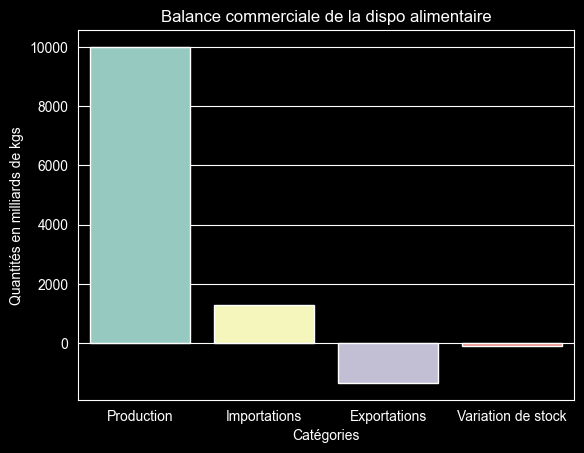

In [64]:
# création du graphique en barres
sns.barplot(x=df_total_balance_provenance_dispo['Catégorie'], y=df_total_balance_provenance_dispo['Valeur_totale en milliards de kgs'], hue=df_total_balance_provenance_dispo['Catégorie'])
plt.title("Balance commerciale de la dispo alimentaire")
plt.xlabel("Catégories")
plt.ylabel("Quantités en milliards de kgs")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [65]:
#Création d'une liste avec toutes les variables
cereales = ['Avoine', 'Blé', 'Céréales, Autres', 'Maïs', 'Millet', 'Orge', 'Riz (Eq Blanchi)', 'Seigle', 'Sorgho']

In [66]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
masque_cereales = dispo_alimentaire['Produit'].isin(cereales)
dispo_cereales = dispo_alimentaire.loc[masque_cereales]
dispo_cereales

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal par jour
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,...,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0,2017,36296113.0,4.968938e+10
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2017,36296113.0,0.000000e+00
32,Afghanistan,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,0.56,3.130000e+08,...,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0,2017,36296113.0,7.622184e+08
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,1.300000e+07,...,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.0,2017,36296113.0,1.088883e+08
40,Afghanistan,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,0.79,5.240000e+08,...,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0,2017,36296113.0,9.436989e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15545,Îles Salomon,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2017,636039.0,0.000000e+00
15568,Îles Salomon,Maïs,vegetale,0.0,0.0,1.0,0.15,0.01,0.03,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2017,636039.0,6.360390e+05
15575,Îles Salomon,Orge,vegetale,0.0,0.0,0.0,0.07,0.00,0.01,1.000000e+06,...,1.000000e+06,0.000000e+00,0.0,0.000000e+00,0.0,1000000.0,0.0,2017,636039.0,0.000000e+00
15591,Îles Salomon,Riz (Eq Blanchi),vegetale,0.0,12000000.0,623.0,63.76,1.36,10.90,4.900000e+07,...,4.700000e+07,3.600000e+07,1000000.0,3.000000e+06,0.0,0.0,0.0,2017,636039.0,3.962523e+08


In [67]:
#Affichage de la proportion d'alimentation animale
proportion_alim_animale = dispo_cereales['Aliments pour animaux'].sum()*100 / dispo_cereales['Disponibilité intérieure'].sum()
print("La proportion d'alimentation animale dans l'utilisation des céréales est de {:.2f}%.".format(proportion_alim_animale))

La proportion d'alimentation animale dans l'utilisation des céréales est de 36.29%.


In [68]:
dispo_cereales_somme = dispo_cereales.groupby('Produit')[['Aliments pour animaux', 'Nourriture', 'Disponibilité intérieure']].sum().reset_index() #création d'un dataframe avec les totaux par céréales où on ne garde que les colonnes qui nous intéressent.
total_animaux = dispo_cereales_somme['Aliments pour animaux'].sum()
total_nourriture = dispo_cereales_somme['Nourriture'].sum()
total_dispo = dispo_cereales_somme['Disponibilité intérieure'].sum()

In [69]:
dispo_cereales_somme

,Produit,Aliments pour animaux,Nourriture,Disponibilité intérieure
0,Avoine,1.625100e+10,3.903000e+09,2.340700e+10
1,Blé,1.296680e+11,4.578240e+11,6.794980e+11
2,"Céréales, Autres",1.903500e+10,5.324000e+09,2.748500e+10
3,Maïs,5.461160e+11,1.251840e+11,9.557990e+11
4,Millet,3.306000e+09,2.304000e+10,2.991100e+10
5,Orge,9.265800e+10,6.794000e+09,1.404390e+11
6,Riz (Eq Blanchi),3.359400e+10,3.772860e+11,4.756560e+11
7,Seigle,8.099000e+09,5.502000e+09,1.656700e+10
8,Sorgho,2.480800e+10,2.415300e+10,5.823700e+10


In [70]:
 #création d'un DF pour avoir une catégorie pour l'ensemble des céréales qu'on va par la suite concaténer à notre DF dispo_cereales_somme.
 # On commence par créer nos variables qui vont être utilisées dans notre futur DF
total_animaux = dispo_cereales_somme['Aliments pour animaux'].sum()
total_nourriture = dispo_cereales_somme['Nourriture'].sum()
total_dispo = dispo_cereales_somme['Disponibilité intérieure'].sum()

#Création du DF
df_categorie_total_cereales = pd.DataFrame({'Produit': ['Total Céréales'],'Aliments pour animaux': [total_animaux],'Nourriture': [total_nourriture],'Disponibilité intérieure': [total_dispo]})

In [71]:
df_categorie_total_cereales

,Produit,Aliments pour animaux,Nourriture,Disponibilité intérieure
0,Total Céréales,8.735350e+11,1.029010e+12,2.406999e+12


In [72]:
# on a bien le même nombre de colonnes, on peut donc concaténer les 2 DFs.
dispo_cereales_somme = pd.concat([dispo_cereales_somme, df_categorie_total_cereales])
#Ajout de deux colonnes pour avoir la proportion pour les deux catégories
dispo_cereales_somme['proportion aliments pour animaux'] = 100 * dispo_cereales_somme['Aliments pour animaux']/ dispo_cereales_somme['Disponibilité intérieure']
dispo_cereales_somme['proportion alimentation humaine'] = 100 * dispo_cereales_somme['Nourriture']/ dispo_cereales_somme['Disponibilité intérieure']

In [73]:
dispo_cereales_somme

,Produit,Aliments pour animaux,Nourriture,Disponibilité intérieure,proportion aliments pour animaux,proportion alimentation humaine
0,Avoine,1.625100e+10,3.903000e+09,2.340700e+10,69.427949,16.674499
1,Blé,1.296680e+11,4.578240e+11,6.794980e+11,19.082911,67.376799
2,"Céréales, Autres",1.903500e+10,5.324000e+09,2.748500e+10,69.255958,19.370566
3,Maïs,5.461160e+11,1.251840e+11,9.557990e+11,57.137118,13.097314
4,Millet,3.306000e+09,2.304000e+10,2.991100e+10,11.052790,77.028518
5,Orge,9.265800e+10,6.794000e+09,1.404390e+11,65.977399,4.837688
6,Riz (Eq Blanchi),3.359400e+10,3.772860e+11,4.756560e+11,7.062667,79.319088
7,Seigle,8.099000e+09,5.502000e+09,1.656700e+10,48.886340,33.210599
8,Sorgho,2.480800e+10,2.415300e+10,5.823700e+10,42.598348,41.473634
0,Total Céréales,8.735350e+11,1.029010e+12,2.406999e+12,36.291457,42.750745


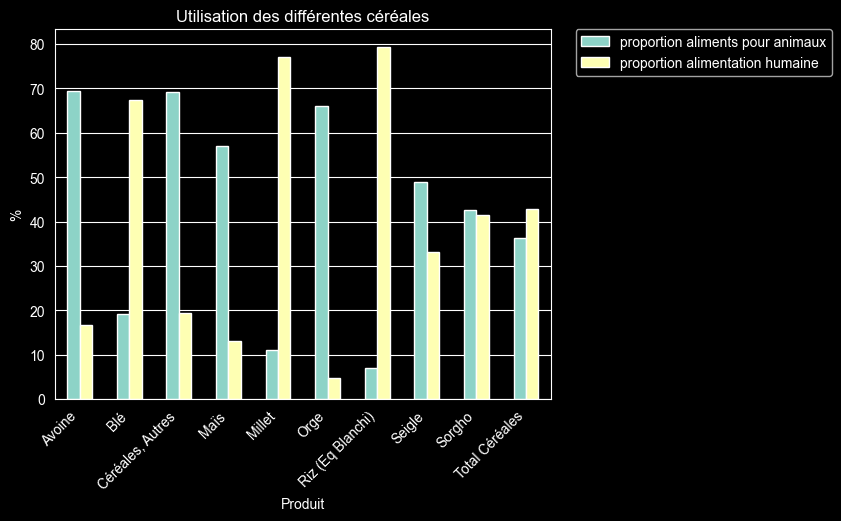

In [74]:
# Création d'un barchart pour représenter les proportions par catégorie de céréale.
dispo_cereales_somme.set_index('Produit')[['proportion aliments pour animaux', 'proportion alimentation humaine']].plot(kind='bar',)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("Utilisation des différentes céréales")
plt.grid(axis='x')
plt.xticks(rotation=45, ha='right')
plt.ylabel('%')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [75]:
#Création de la colonne proportion par pays
proportion_sous_nutrition_2017['Proportion en %'] = proportion_sous_nutrition_2017['sous_nutrition']*100 / proportion_sous_nutrition_2017['Population']

<Axes: title={'center': 'Top 10 pays avec le plus fort taux de sous-nutrition en 2017.'}, xlabel='Zone', ylabel='%'>

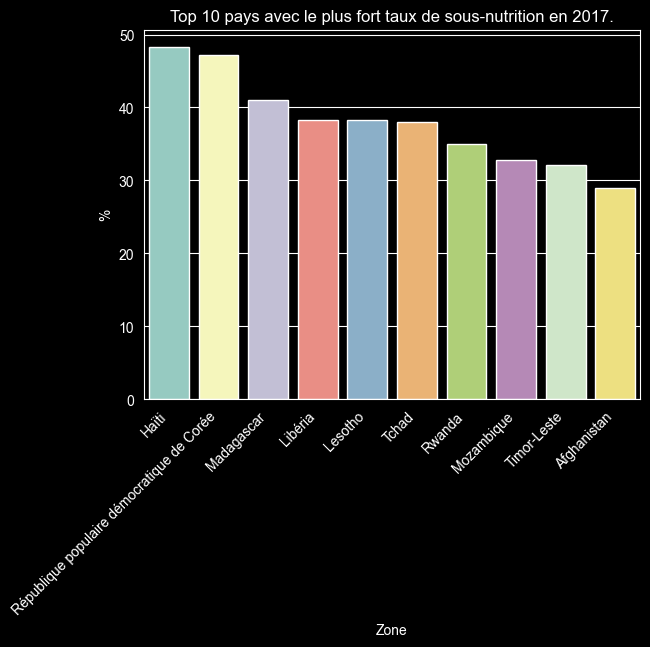

In [76]:
#affichage après trie des 10 pires pays
proportion_sous_nutrition_2017.sort_values('Proportion en %', ascending=False,  inplace=True)

#nouveau DF ne contenant que les 10 pires pays
top_10_pays_sous_nutrition = proportion_sous_nutrition_2017.head(10)

plt.xticks(rotation=45, ha='right')
plt.ylabel('%')
plt.title("Top 10 pays avec le plus fort taux de sous-nutrition en 2017.")
sns.barplot(data=top_10_pays_sous_nutrition, x='Zone', y='Proportion en %', hue='Zone')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [77]:
#calcul du total de l'aide alimentaire par pays
total_aide_pays = aide_alimentaire.groupby('Zone')['Valeur'].sum().reset_index()
#conversion en milliards de kg pour plus de clarté
total_aide_pays['Valeur'] /= 10**9

<Axes: title={'center': "Top 10 pays qui ont bénéficié le plus de l'aide alimentaire depuis 2013"}, xlabel='Zone', ylabel='Aide totale en milliards de kgs'>

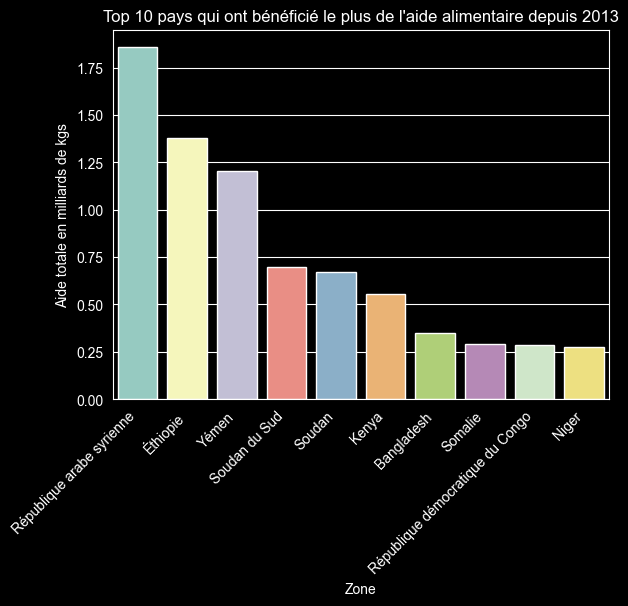

In [78]:
#affichage après tri des 10 pays qui ont bénéficié le plus de l'aide alimentaire
total_aide_pays.sort_values(by='Valeur', ascending=False, inplace=True)

#création d'un DF avec les 10 pays
top_10_pays_aide = total_aide_pays.head(10)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Aide totale en milliards de kgs')
plt.title("Top 10 pays qui ont bénéficié le plus de l'aide alimentaire depuis 2013")
sns.barplot(data=top_10_pays_aide, x='Zone', y='Valeur', hue='Zone')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [79]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année (il y a une entrée pour chaque produit dans chaque pays chaque année, il faut agréger cela)
aide_alimentaire_evolution = aide_alimentaire[['Zone', 'Année', 'Valeur']]
aide_alimentaire_evolution = aide_alimentaire_evolution.groupby(['Zone', 'Année']).sum().reset_index()
aide_alimentaire_evolution

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


In [80]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficié de l'aide alimentaire
liste_top_5 = total_aide_pays['Zone'].head(5).tolist()
print(liste_top_5)

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [81]:
#On filtre sur le dataframe avec notre liste
mask_top5_aide = aide_alimentaire_evolution['Zone'].isin(liste_top_5)
evolution_aide_top5 = aide_alimentaire_evolution.loc[mask_top5_aide]
evolution_aide_top5

,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


In [82]:
evolution_aide_top5['Valeur'] = pd.to_numeric(evolution_aide_top5['Valeur'], errors='coerce') #changement des valeurs en numérique pour pouvoir les diviser en millions de kgs pour plus de clarté
evolution_aide_top5['Valeur'] /= (10**6)


C:\Users\MonCompte\AppData\Local\Temp\ipykernel_32484\3337940926.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evolution_aide_top5['Valeur'] = pd.to_numeric(evolution_aide_top5['Valeur'], errors='coerce') #changement des valeurs en numérique pour pouvoir les diviser en millions de kgs pour plus de clarté
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_32484\3337940926.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evolution_aide_top5['Valeur'] /= (10**6)


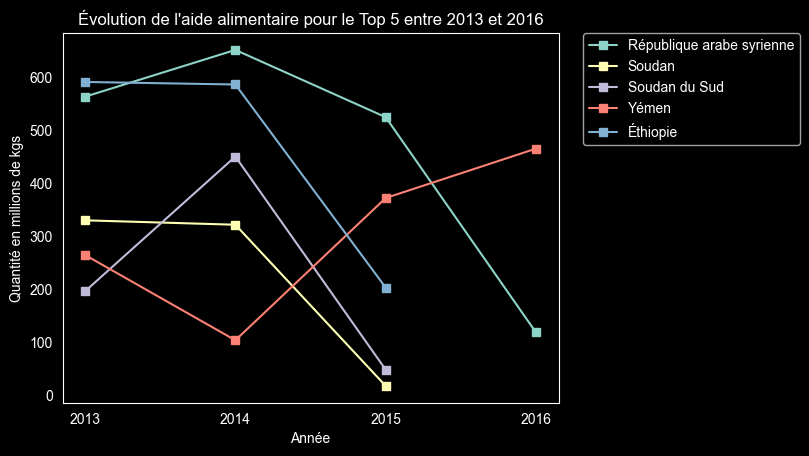

In [83]:
# Affichage des pays avec l'aide alimentaire par année",
evolution_aide_top5.pivot(index='Année', columns='Zone', values='Valeur').plot(kind='line', marker='s')
plt.xticks([2013, 2014, 2015, 2016])
plt.title("Évolution de l'aide alimentaire pour le Top 5 entre 2013 et 2016")
plt.ylabel("Quantité en millions de kgs")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(None)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [84]:
#Calcul de la disponibilité en kcal par personne par jour par pays
# On crée un DF avec la somme de dispo par pays
dispo_par_pays = dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()
dispo_par_pays

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0
...,...,...
169,Émirats arabes unis,3275.0
170,Équateur,2346.0
171,États-Unis d'Amérique,3682.0
172,Éthiopie,2129.0


<Axes: title={'center': 'Top 10 pays qui ont le moins de dispo alimentaire par personne en 2017'}, xlabel='Zone', ylabel='dispo totale kcal/pers/jour'>

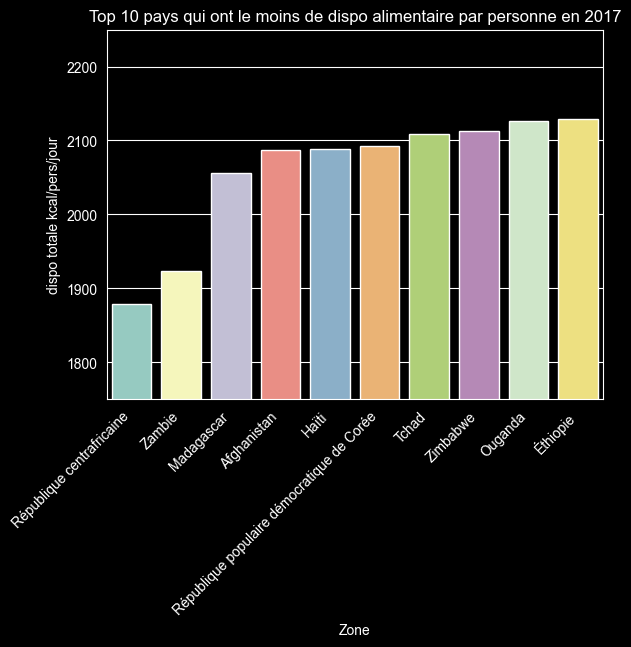

In [85]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
#On trie avec ascending True pour avoir les 10 pires en 1er
dispo_par_pays_asc = dispo_par_pays.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=True)

top_10_pays_dispo_asc = dispo_par_pays_asc.head(10)

plt.xticks(rotation=45, ha='right')
plt.ylim(1750, 2250)
plt.ylabel('dispo totale kcal/pers/jour')
plt.title("Top 10 pays qui ont le moins de dispo alimentaire par personne en 2017")
sns.barplot(data=top_10_pays_dispo_asc, x='Zone', y='Disponibilité alimentaire (Kcal/personne/jour)', hue='Zone')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

<Axes: title={'center': 'Top 10 pays qui ont le plus de dispo alimentaire par personne en 2017'}, xlabel='Zone', ylabel='dispo totale kcal/pers/jour'>

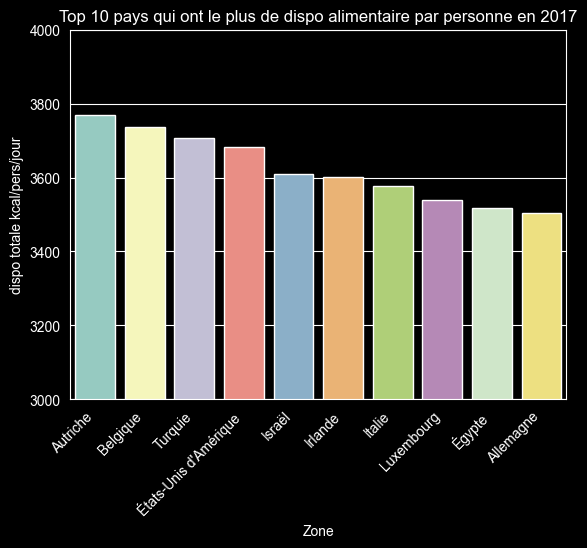

In [86]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
#On trie avec ascending False pour avoir les 10 meilleurs en 1er
dispo_par_pays_desc = dispo_par_pays.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False)
dispo_par_pays_desc.head(10)

top_10_pays_dispo_desc = dispo_par_pays_desc.head(10).head(10)

plt.xticks(rotation=45, ha='right')
plt.ylim(3000, 4000)
plt.ylabel('dispo totale kcal/pers/jour')
plt.title("Top 10 pays qui ont le plus de dispo alimentaire par personne en 2017")
sns.barplot(data=top_10_pays_dispo_desc, x='Zone', y='Disponibilité alimentaire (Kcal/personne/jour)', hue='Zone')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [87]:
#création d'un dataframe avec uniquement la Thaïlande 
df_thailande = dispo_alimentaire.loc[dispo_alimentaire['Zone'] == 'Thaïlande']
df_thailande

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,dispo_kcal par jour
13759,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000000.0,...,33000000.0,75000000.0,0.0,4.500000e+07,0.0,0.0,0.0,2017,69209810.0,2.076294e+08
13760,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000000.0,...,2000000.0,6000000.0,0.0,1.200000e+07,0.0,2000000.0,0.0,2017,69209810.0,0.000000e+00
13761,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000000.0,0.0,0.00,0.00,0.00,358000000.0,...,21000000.0,0.0,0.0,4.470000e+08,0.0,0.0,0.0,2017,69209810.0,0.000000e+00
13762,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000000.0,...,19000000.0,12000000.0,0.0,0.000000e+00,0.0,0.0,0.0,2017,69209810.0,1.384196e+08
13763,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000000.0,...,9000000.0,671000000.0,110000000.0,2.209000e+09,0.0,0.0,13000000.0,2017,69209810.0,6.920981e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13849,Thaïlande,Viande de Suides,animale,0.0,0.0,124.0,13.00,11.83,3.92,871000000.0,...,1000000.0,871000000.0,0.0,8.910000e+08,0.0,0.0,0.0,2017,69209810.0,8.582016e+09
13850,Thaïlande,Viande de Volailles,animale,0.0,0.0,52.0,13.69,3.62,4.49,945000000.0,...,11000000.0,917000000.0,28000000.0,1.470000e+09,0.0,0.0,0.0,2017,69209810.0,3.598910e+09
13851,Thaïlande,"Viande, Autre",animale,0.0,0.0,0.0,0.03,0.01,0.02,-92000000.0,...,4000000.0,2000000.0,0.0,0.000000e+00,0.0,0.0,0.0,2017,69209810.0,0.000000e+00
13852,Thaïlande,Vin,vegetale,0.0,0.0,0.0,0.12,0.00,0.00,8000000.0,...,16000000.0,8000000.0,0.0,0.000000e+00,0.0,0.0,0.0,2017,69209810.0,0.000000e+00


In [88]:
#Calcul de la sous nutrition en Thaïlande
sous_nutrition_thai = proportion_sous_nutrition_2017.loc[proportion_sous_nutrition_2017['Zone'] == 'Thaïlande']
sous_nutrition_thai

,Zone,Année,sous_nutrition,Population,Proportion en %
185,Thaïlande,2017,6200000.0,69209810.0,8.958268


In [89]:
# On calcule la proportion exportée en fonction de la production
# Regarder les exportations et la production de Manioc
# On crée un DF avec seulement la thaïlande et le manioc
df_thailande_manioc = df_thailande.loc[df_thailande['Produit']=='Manioc', ['Zone', 'Produit', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Exportations - Quantité', 'Production']]
#Création d'une colonne proportion exportation sur production
df_thailande_manioc['proportion exportation sur production'] = df_thailande_manioc['Exportations - Quantité'] * 100 / df_thailande_manioc['Production']

print(f"La proportion de Manioc exporté sur la production en Thaïlande est de {round(df_thailande_manioc['proportion exportation sur production'].sum(), 2)}%.")


La proportion de Manioc exporté sur la production en Thaïlande est de 83.41%.


In [90]:
df_thailande_manioc

,Zone,Produit,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité alimentaire (Kcal/personne/jour),Exportations - Quantité,Production,proportion exportation sur production
13809,Thaïlande,Manioc,13.0,40.0,2.521400e+10,3.022800e+10,83.41273


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [91]:
#ajouter en dessous toutes les analyses complémtaires

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Comparaison de l'aide alimentaire par rapport à la sous nutrition chaque année</h2>
</div>

In [92]:
aide_alimentaire['Année'].unique()

array([2013, 2014, 2015, 2016])

In [93]:
sous_nutrition.fillna(0, inplace=True)

In [94]:
somme_aide_par_an_et_pays = aide_alimentaire.groupby(by=['Zone', 'Année'])['Valeur'].sum().reset_index()
somme_aide_par_an_et_pays.head()

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000


In [95]:
# On vérifie que les deux colonnes 'Zone' ont bien les mêmes données :
manquants_sous_nutrition = somme_aide_par_an_et_pays[~somme_aide_par_an_et_pays['Zone'].isin(sous_nutrition['Zone'])]
# On cherche les pays qui ne sont PAS présents grâce à '~'.
manquants_aide = sous_nutrition[~sous_nutrition['Zone'].isin(somme_aide_par_an_et_pays['Zone'])]
print(f"Pays dans aide mais pas dans sous_nutrition: {len(manquants_sous_nutrition)}")
print(f"Pays dans sous_nutrition mais pas dans aide: {len(manquants_aide)}")

Pays dans aide mais pas dans sous_nutrition: 2
Pays dans sous_nutrition mais pas dans aide: 768


In [96]:
print(manquants_sous_nutrition)
print(manquants_aide)

          Zone  Année    Valeur
199  Swaziland   2013  12818000
200  Swaziland   2014   2710000
                Zone  Année  sous_nutrition
6     Afrique du Sud   2013       2200000.0
7     Afrique du Sud   2014       2500000.0
8     Afrique du Sud   2015       2800000.0
9     Afrique du Sud   2016       3000000.0
10    Afrique du Sud   2017       3100000.0
...              ...    ...             ...
1195        Viet Nam   2014       8300000.0
1196        Viet Nam   2015       7600000.0
1197        Viet Nam   2016       7100000.0
1198        Viet Nam   2017       6500000.0
1199        Viet Nam   2018       6100000.0

[768 rows x 3 columns]


In [97]:
# on merge nos deux DF dans un seul en faisant une jointure à gauche sur somme_aide_par_an_et_pays
aide_sous_nutrition = pd.merge(somme_aide_par_an_et_pays, sous_nutrition, on=['Zone', 'Année'], how="left")
# On nettoie notre DF en enlevant les lignes ayant une valeur nulle sur les colonnes aides ou sous nutrition
aide_sous_nutrition = aide_sous_nutrition.dropna(subset=["sous_nutrition", "Valeur"])

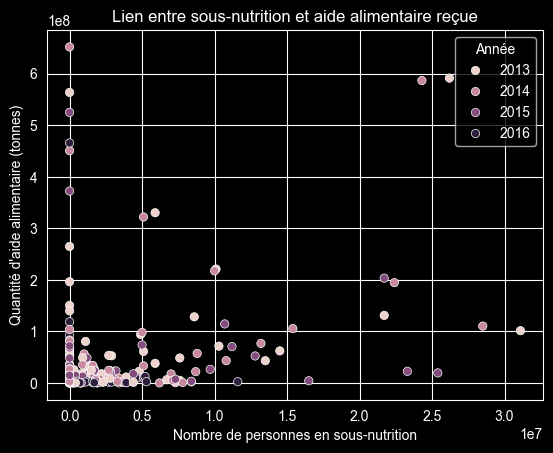

Coefficient de corrélation : 0.267
P-value : 4.915e-05


In [111]:
# Graph en nuage de points entre les deux variables sur toutes les années

sns.scatterplot(data=aide_sous_nutrition, x="sous_nutrition", y="Valeur", hue='Année')
plt.title("Lien entre sous-nutrition et aide alimentaire reçue")
plt.xlabel("Nombre de personnes en sous-nutrition")
plt.ylabel("Quantité d'aide alimentaire (tonnes)")
plt.show()

#Ajout du R² et de la p-value
import scipy.stats as st

print(f"Coefficient de corrélation : {st.pearsonr(aide_sous_nutrition["sous_nutrition"],aide_sous_nutrition["Valeur"])[0]:.3f}")
print(f"P-value : {st.pearsonr(aide_sous_nutrition["sous_nutrition"],aide_sous_nutrition["Valeur"])[1]:.3e}")

Coefficient de corrélation : 0.267
P-value : 4.915e-05


Coefficient de corrélation : 0.380
P-value : 1.083e-03


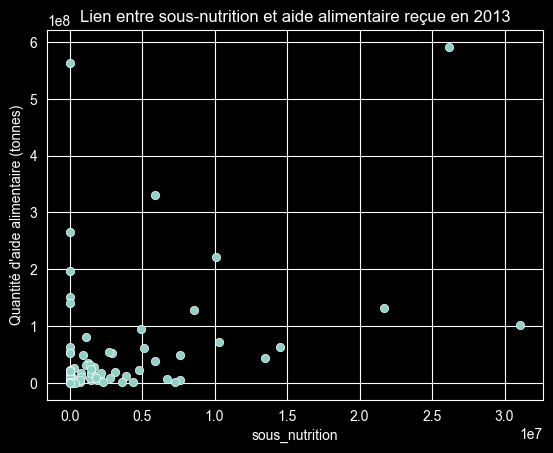

Coefficient de corrélation : 0.358
P-value : 2.529e-03


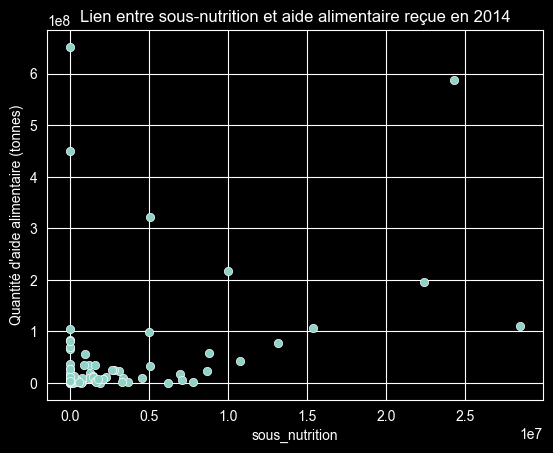

Coefficient de corrélation : 0.058
P-value : 6.581e-01


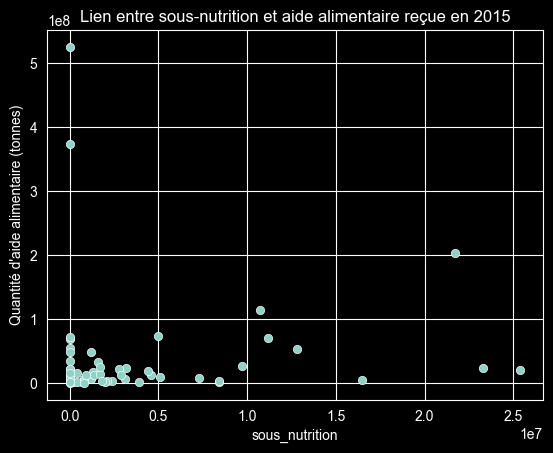

Coefficient de corrélation : -0.227
P-value : 2.656e-01


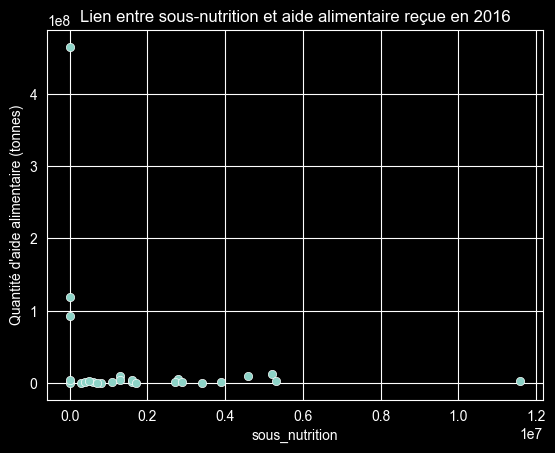

In [100]:
#On va produire une série de nuages pour chaque année et observer si certaines sont plus corrélées que d'autres

liste_annees = aide_sous_nutrition['Année'].unique() # on fait une liste avec les années pour faire une boucle for dessus et créer un graph par an

for year in liste_annees:
    df = aide_sous_nutrition.loc[aide_sous_nutrition["Année"] == year]
    sns.scatterplot(data=df, x="sous_nutrition", y="Valeur")
    plt.title("Lien entre sous-nutrition et aide alimentaire reçue en {0}".format(year))
    plt.ylabel("Quantité d'aide alimentaire (tonnes)")
    print(f"Coefficient de corrélation : {st.pearsonr(df["sous_nutrition"],df["Valeur"])[0]:.3f}")
    print(f"P-value : {st.pearsonr(df["sous_nutrition"],df["Valeur"])[1]:.3e}")
    plt.show()

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Analyse des pertes</h2>
</div>

In [101]:
# Dataframe avec le total de pertes par pays

dispo_alimentaire_pertes = dispo_alimentaire.groupby(by='Zone')['Pertes'].sum().reset_index()
dispo_alimentaire_pertes

,Zone,Pertes
0,Afghanistan,1.135000e+09
1,Afrique du Sud,2.193000e+09
2,Albanie,2.760000e+08
3,Algérie,3.753000e+09
4,Allemagne,3.781000e+09
...,...,...
169,Émirats arabes unis,7.050000e+08
170,Équateur,7.070000e+08
171,États-Unis d'Amérique,7.162000e+09
172,Éthiopie,2.256000e+09


In [102]:
#Je veux merge sous nutrition dans dispo_alimentaire_pertes, je vais donc faire la vérification habituelle de mes colonnes de jointure

In [103]:
# On vérifie que les deux colonnes 'Zone' ont bien les mêmes données :
manquants_sous_nutrition = dispo_alimentaire_pertes[~dispo_alimentaire_pertes['Zone'].isin(sous_nutrition_2017['Zone'])]
# On cherche les pays qui ne sont PAS présents grâce à '~'.
manquants_pertes = sous_nutrition_2017[~sous_nutrition_2017['Zone'].isin(dispo_alimentaire_pertes['Zone'])]
print(f"Pays dans pertes mais pas dans sous_nutrition: {len(manquants_sous_nutrition)}")
print(f"Pays dans sous_nutrition mais pas dans pertes: {len(manquants_pertes)}")

Pays dans pertes mais pas dans sous_nutrition: 2
Pays dans sous_nutrition mais pas dans pertes: 31


In [104]:
sous_nutrition_2017.loc[sous_nutrition_2017['Zone'] == "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord", 'Zone'] = 'Royaume-Uni'
sous_nutrition_2017.loc[sous_nutrition_2017['Zone'] == "Tchéquie", 'Zone'] = 'Tchéquie (la)'

In [105]:
# On vérifie que les deux colonnes 'Zone' ont bien les mêmes données :
manquants_sous_nutrition = dispo_alimentaire_pertes[~dispo_alimentaire_pertes['Zone'].isin(sous_nutrition_2017['Zone'])]
# On cherche les pays qui ne sont PAS présents grâce à '~'.
manquants_pertes = sous_nutrition_2017[~sous_nutrition_2017['Zone'].isin(dispo_alimentaire_pertes['Zone'])]
print(f"Pays dans pertes mais pas dans sous_nutrition: {len(manquants_sous_nutrition)}")
print(f"Pays dans sous_nutrition mais pas dans pertes: {len(manquants_pertes)}")

Pays dans pertes mais pas dans sous_nutrition: 0
Pays dans sous_nutrition mais pas dans pertes: 29


In [106]:
# Je peux maintenant faire ma jointure
perte_vs_sous_nutrition = pd.merge(dispo_alimentaire_pertes, sous_nutrition_2017, on='Zone', how='left')
perte_vs_sous_nutrition

,Zone,Pertes,Année,sous_nutrition
0,Afghanistan,1.135000e+09,2017,10500000.0
1,Afrique du Sud,2.193000e+09,2017,3100000.0
2,Albanie,2.760000e+08,2017,100000.0
3,Algérie,3.753000e+09,2017,1300000.0
4,Allemagne,3.781000e+09,2017,NaN
...,...,...,...,...
169,Émirats arabes unis,7.050000e+08,2017,300000.0
170,Équateur,7.070000e+08,2017,1500000.0
171,États-Unis d'Amérique,7.162000e+09,2017,NaN
172,Éthiopie,2.256000e+09,2017,21100000.0


In [107]:
# Création d'une colonne avec la perte par personne en sous nutrition dans chaque pays
perte_vs_sous_nutrition['kg pertes / personnes en sous nutrition / an'] = perte_vs_sous_nutrition['Pertes'] / perte_vs_sous_nutrition['sous_nutrition']
perte_vs_sous_nutrition.dropna(inplace=True)

In [108]:
perte_vs_sous_nutrition

,Zone,Pertes,Année,sous_nutrition,kg pertes / personnes en sous nutrition / an
0,Afghanistan,1.135000e+09,2017,10500000.0,108.095238
1,Afrique du Sud,2.193000e+09,2017,3100000.0,707.419355
2,Albanie,2.760000e+08,2017,100000.0,2760.000000
3,Algérie,3.753000e+09,2017,1300000.0,2886.923077
5,Angola,4.799000e+09,2017,5800000.0,827.413793
...,...,...,...,...,...
164,Viet Nam,6.743000e+09,2017,6500000.0,1037.384615
168,Égypte,7.608000e+09,2017,4600000.0,1653.913043
169,Émirats arabes unis,7.050000e+08,2017,300000.0,2350.000000
170,Équateur,7.070000e+08,2017,1500000.0,471.333333


<Axes: title={'center': 'Top 10 pays qui ont le plus de pertes alimentaire par personne en sous nutrition'}, xlabel='Zone', ylabel='kg / personne en sous-nutrition / an'>

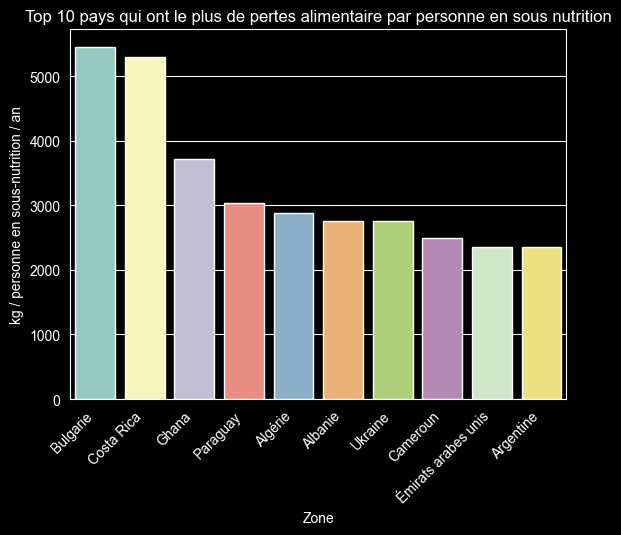

In [109]:
#Affichage des 10 pays qui ont le plus de kgs de nourriture perdu par personne en sous nutrition.
perte_vs_sous_nutrition = perte_vs_sous_nutrition.sort_values(by='kg pertes / personnes en sous nutrition / an', ascending=False)

perte_vs_sous_nutrition_top10 = perte_vs_sous_nutrition.head(10)

plt.xticks(rotation=45, ha='right')
plt.ylim()
plt.ylabel('kg / personne en sous-nutrition / an')
plt.title("Top 10 pays qui ont le plus de pertes alimentaire par personne en sous nutrition")
sns.barplot(data=perte_vs_sous_nutrition_top10, x='Zone', y='kg pertes / personnes en sous nutrition / an', hue='Zone')